<a href="https://colab.research.google.com/github/bahawal-khan/DeepLearning-practice/blob/main/CNN/Dogs_vs_Cats_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bahawalk","key":"784fac966a9b219f2318484220efb819"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle datasets list -s dogs-vs-cats

ref                                                    title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset             Cats-vs-Dogs                                    825979578  2020-03-12 05:34:30.730000         109864        983  0.875            
biaiscience/dogs-vs-cats                               Dogs vs Cats                                    856265363  2017-12-05 14:03:33.210000          32254        366  0.4375           
pybear/cats-vs-dogs                                    Cats -- VS -- Dogs                              825979578  2020-10-18 13:55:30.950000           3331        106  0.625            
sujaykapadnis/cats-vs-dogs                             Cats Vs Dogs   

In [8]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:12<00:00, 92.6MB/s]



In [9]:
!unzip dogsvscats.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/train/dogs/dog.4419.jpg  
  inflating: dataset/train/dogs/dog.442.jpg  
  inflating: dataset/train/dogs/dog.4420.jpg  
  inflating: dataset/train/dogs/dog.4421.jpg  
  inflating: dataset/train/dogs/dog.4422.jpg  
  inflating: dataset/train/dogs/dog.4424.jpg  
  inflating: dataset/train/dogs/dog.4425.jpg  
  inflating: dataset/train/dogs/dog.4426.jpg  
  inflating: dataset/train/dogs/dog.4427.jpg  
  inflating: dataset/train/dogs/dog.4431.jpg  
  inflating: dataset/train/dogs/dog.4433.jpg  
  inflating: dataset/train/dogs/dog.4436.jpg  
  inflating: dataset/train/dogs/dog.4438.jpg  
  inflating: dataset/train/dogs/dog.4439.jpg  
  inflating: dataset/train/dogs/dog.444.jpg  
  inflating: dataset/train/dogs/dog.4440.jpg  
  inflating: dataset/train/dogs/dog.4441.jpg  
  inflating: dataset/train/dogs/dog.4442.jpg  
  inflating: dataset/train/dogs/dog.4443.jpg  
  inflating: dataset/train/dogs/dog.4444.jpg  
  inflating

In [19]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [11]:
train_dataset = keras.utils.image_dataset_from_directory(
    directory = '/content/dataset/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)


validation_dataset = keras.utils.image_dataset_from_directory(
    directory = '/content/dataset/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [12]:
def process(image,label):
  image = tf.cast(image/255,tf.float32)
  return image,label
train_ds = train_dataset.map(process)
validation_ds = validation_dataset.map(process)

CNN Model

In [20]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding = 'valid',activation= 'relu',input_shape = (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2),strides = 2,padding = 'valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding = 'valid',activation= 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2),strides = 2,padding = 'valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding = 'valid',activation= 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2),strides = 2,padding = 'valid'))

model.add(Flatten())

model.add(Dense(128,activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
model.compile(optimizer = 'adam',loss = 'binary_crossentropy',metrics = ['accuracy'])

In [23]:
history = model.fit(train_ds,epochs = 10,validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 101ms/step - accuracy: 0.5593 - loss: 1.3497 - val_accuracy: 0.5958 - val_loss: 0.6558
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.6076 - loss: 0.6581 - val_accuracy: 0.6346 - val_loss: 0.6794
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.6558 - loss: 0.6262 - val_accuracy: 0.6312 - val_loss: 0.6543
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.6876 - loss: 0.6005 - val_accuracy: 0.5392 - val_loss: 0.7233
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 91ms/step - accuracy: 0.7253 - loss: 0.5541 - val_accuracy: 0.7310 - val_loss: 0.5513
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.7351 - loss: 0.5467 - val_accuracy: 0.7496 - val_loss: 0.5371
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7622 - loss: 0.5040 - val_accuracy: 0.7400 - val_loss: 0.5420
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7768 - loss: 0.4861 -

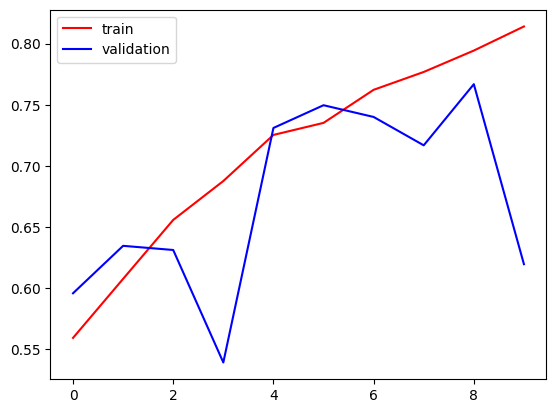

In [24]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color =  'red',label = 'train')
plt.plot(history.history['val_accuracy'],color = 'blue',label = 'validation')
plt.legend()
plt.show()

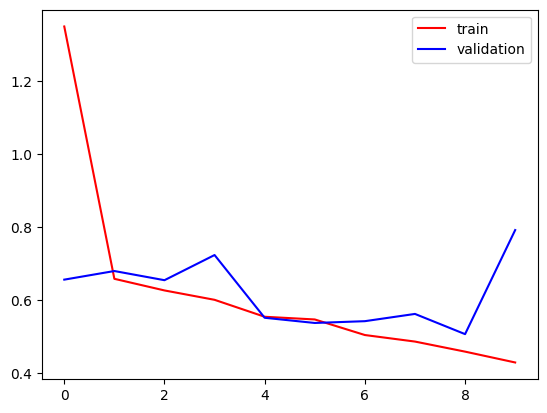

In [25]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color =  'red',label = 'train')
plt.plot(history.history['val_loss'],color = 'blue',label = 'validation')
plt.legend()
plt.show()

Check the model on Unseen Data

In [26]:
import cv2

In [27]:
test_img = cv2.imread('/content/cat.jpg')


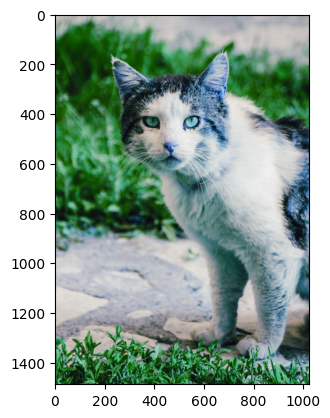

In [28]:
plt.imshow(test_img)

In [30]:
test_img.shape

(1488, 1024, 3)

In [33]:
import numpy as np

test_img = cv2.resize(test_img,(256,256))


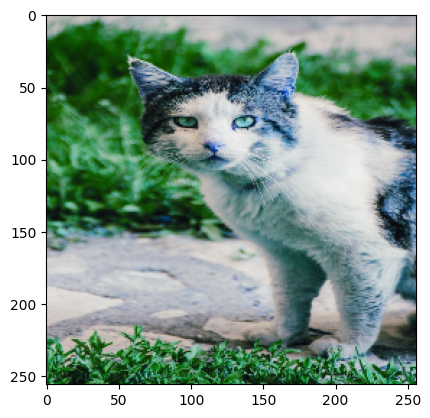

In [34]:
plt.imshow(test_img)

In [35]:
test_img.shape

(256, 256, 3)

In [37]:
test_input = test_img.reshape((1,256,256,3))

In [38]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.14949028]], dtype=float32)

In [39]:
import cv2

In [49]:
test_img1 = cv2.imread('/content/dog1.jpg')

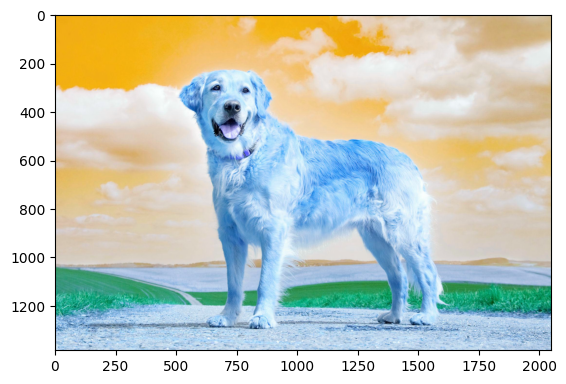

In [50]:
plt.imshow(test_img1)

In [51]:
test_img1.shape

(1384, 2048, 3)

In [53]:
test_img1 =cv2.resize(test_img1,(256,256))

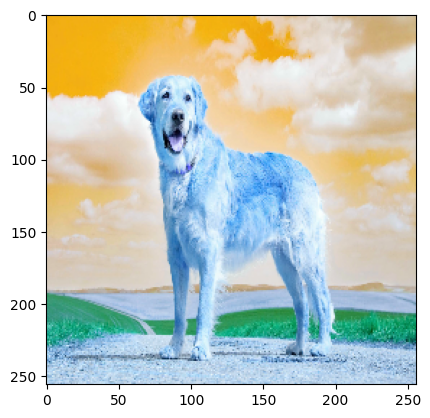

In [54]:
plt.imshow(test_img1)

In [55]:
test_img1_input = test_img1.reshape((1,256,256,3))

In [56]:
model.predict(test_img1_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[0.14949028]], dtype=float32)

In [58]:
print(train_dataset.class_names)

['cats', 'dogs']


In [63]:
import cv2

In [67]:
test_img2 = cv2.imread('/content/dog2.jpg')

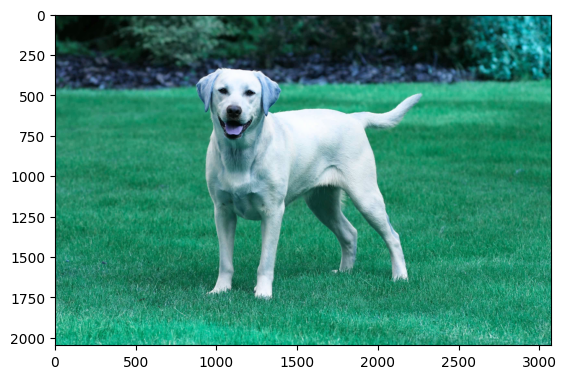

In [68]:
plt.imshow(test_img2)

In [70]:
test_img2.shape

(2048, 3072, 3)

In [71]:
test_img2 =cv2.resize(test_img2,(256,256))

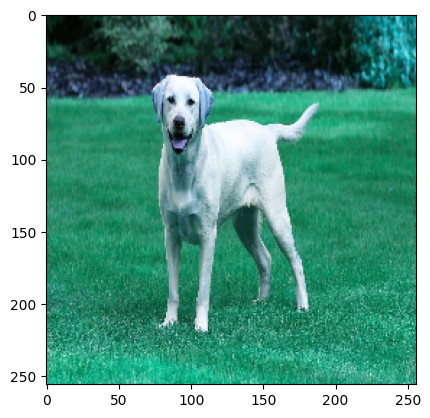

In [72]:
plt.imshow(test_img2)

In [73]:
test_img2_input = test_img2.reshape((1,256,256,3))

In [74]:
model.predict(test_img2_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[1.]], dtype=float32)